# Prediccion de paro cardiaco

Notebook basado en `heart_failure.ipynb`, adaptado para usar el dataset `Medicaldataset.csv` de la carpeta `Base-de-datos`.

El flujo conserva la idea principal del notebook original:

1. Importar librerias.
2. Cargar y explorar el dataset.
3. Preparar la variable objetivo `Result`.
4. Escalar variables predictoras.
5. Entrenar modelos supervisados: SVM, KNN y Regresion Logistica.
6. Comparar metricas y revisar el mejor modelo.

En este dataset, `Result` indica si el caso es `positive` o `negative`. Para modelado se codifica como `positive = 1` y `negative = 0`.

## 1. Importar librerias

Se cargan las librerias necesarias para analisis de datos, visualizacion, preprocesamiento, entrenamiento y evaluacion de modelos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

sns.set_style("whitegrid")
%matplotlib inline

## 2. Cargar el dataset

El notebook original cargaba `heart_failure_clinical_records_dataset.csv.xls`. En este proyecto se usa `Medicaldataset.csv`, ubicado dentro de `Base-de-datos`.

Se dejan dos rutas posibles para que funcione tanto si el notebook se ejecuta desde la carpeta `Supervisado` como desde la raiz del repositorio.

In [2]:
DATA_PATH_CANDIDATES = [
    Path("../Base-de-datos/raw/Medicaldataset.csv"),
    Path("Base-de-datos/raw/Medicaldataset.csv"),
]

DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontro Medicaldataset.csv en Base-de-datos/raw. Revisa la ruta del archivo.")

data_df = pd.read_csv(DATA_PATH)

print(f"Dataset cargado desde: {DATA_PATH}")
print(f"Filas y columnas: {data_df.shape}")
data_df.head()


Dataset cargado desde: ..\Base-de-datos\raw\Medicaldataset.csv
Filas y columnas: (1319, 9)


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


## 3. Exploracion inicial

Se revisan tipos de datos, estadisticas descriptivas, valores faltantes y distribucion de la variable objetivo.

In [3]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   str    
dtypes: float64(3), int64(5), str(1)
memory usage: 92.9 KB


In [4]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1319.0,56.191812,13.647315,14.000,47.000,58.000,65.0000,103.0
Gender,1319.0,0.659591,0.474027,0.000,0.000,1.000,1.0000,1.0
Heart rate,1319.0,78.336619,51.630270,20.000,64.000,74.000,85.0000,1111.0
Systolic blood pressure,1319.0,127.170584,26.122720,42.000,110.000,124.000,143.0000,223.0
Diastolic blood pressure,1319.0,72.269143,14.033924,38.000,62.000,72.000,81.0000,154.0
Blood sugar,1319.0,146.634344,74.923045,35.000,98.000,116.000,169.5000,541.0
CK-MB,1319.0,15.274306,46.327083,0.321,1.655,2.850,5.8050,300.0
Troponin,1319.0,0.360942,1.154568,0.001,0.006,0.014,0.0855,10.3


In [5]:
print("Valores faltantes por columna:")
display(data_df.isnull().sum())

print("\nDistribucion de Result:")
display(data_df["Result"].value_counts())

Valores faltantes por columna:


Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64


Distribucion de Result:


Result
positive    810
negative    509
Name: count, dtype: int64

C:\Users\mafig\AppData\Local\Temp\ipykernel_30212\2858876372.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data_df, x="Result", palette="Set1")


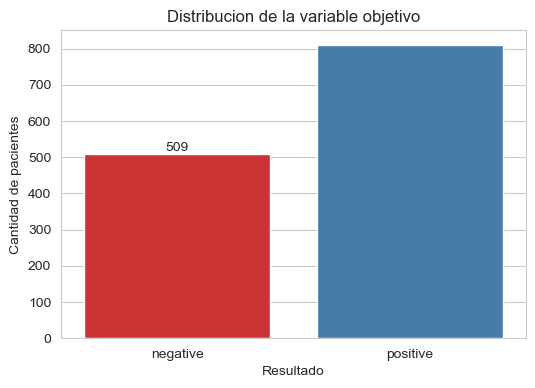

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data_df, x="Result", palette="Set1")
ax.bar_label(ax.containers[0])
plt.title("Distribucion de la variable objetivo")
plt.xlabel("Resultado")
plt.ylabel("Cantidad de pacientes")
plt.show()

## 4. Preparar la variable objetivo

Los modelos de scikit-learn necesitan una variable objetivo numerica. Por eso se transforma `Result` asi:

- `negative` -> `0`
- `positive` -> `1`

In [7]:
data_model = data_df.copy()
data_model["Result"] = data_model["Result"].str.strip().str.lower()
data_model["Result"] = data_model["Result"].map({"negative": 0, "positive": 1})

if data_model["Result"].isnull().any():
    invalid_values = data_df.loc[data_model["Result"].isnull(), "Result"].unique()
    raise ValueError(f"Valores no reconocidos en Result: {invalid_values}")

CLEANED_DATA_DIR = DATA_PATH.parent.parent / "cleaned"
CLEANED_DATA_DIR.mkdir(parents=True, exist_ok=True)
CLEANED_DATA_PATH = CLEANED_DATA_DIR / "Medicaldataset_cleaned.csv"
data_model.to_csv(CLEANED_DATA_PATH, index=False)
print(f"Dataset limpio guardado en: {CLEANED_DATA_PATH}")

data_model.head()


Dataset limpio guardado en: ..\Base-de-datos\cleaned\Medicaldataset_cleaned.csv


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0


## 5. Analisis bivariado

Se revisa la matriz de correlacion ya con `Result` codificado. Esto ayuda a observar que variables tienen mayor relacion lineal con el resultado.

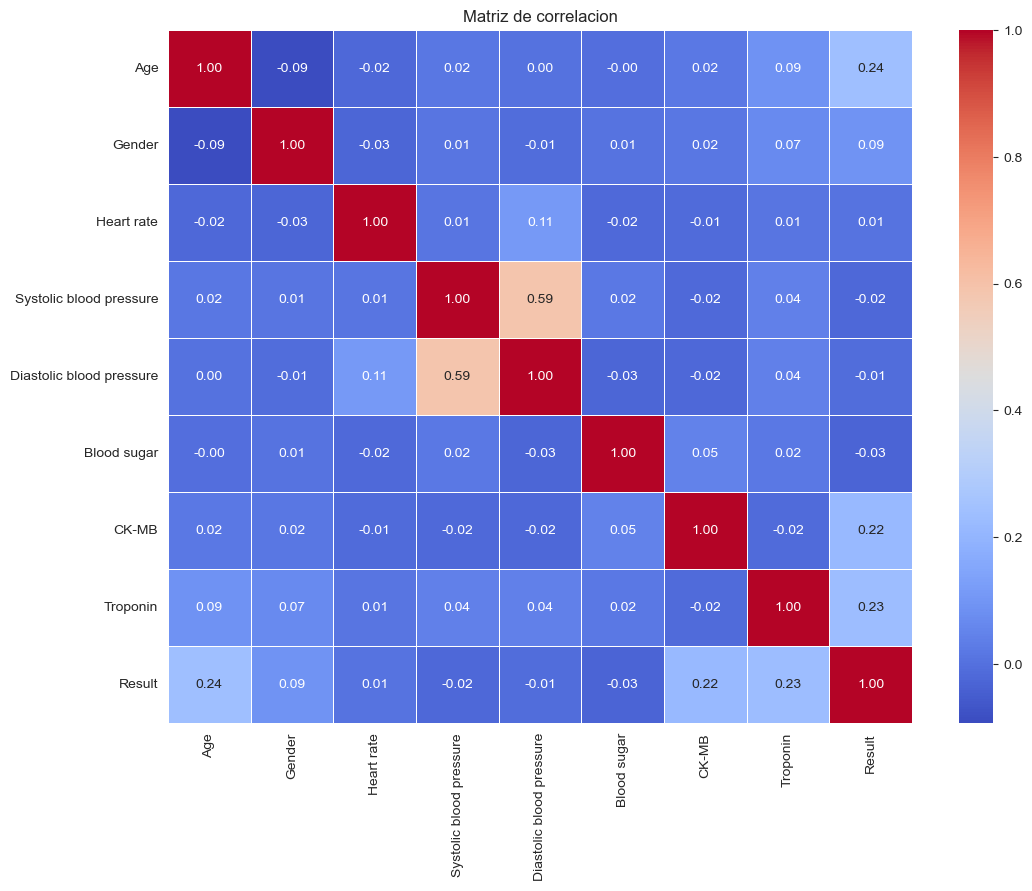

In [8]:
plt.figure(figsize=(12, 9))
corrmat = data_model.corr(numeric_only=True)
sns.heatmap(corrmat, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlacion")
plt.show()

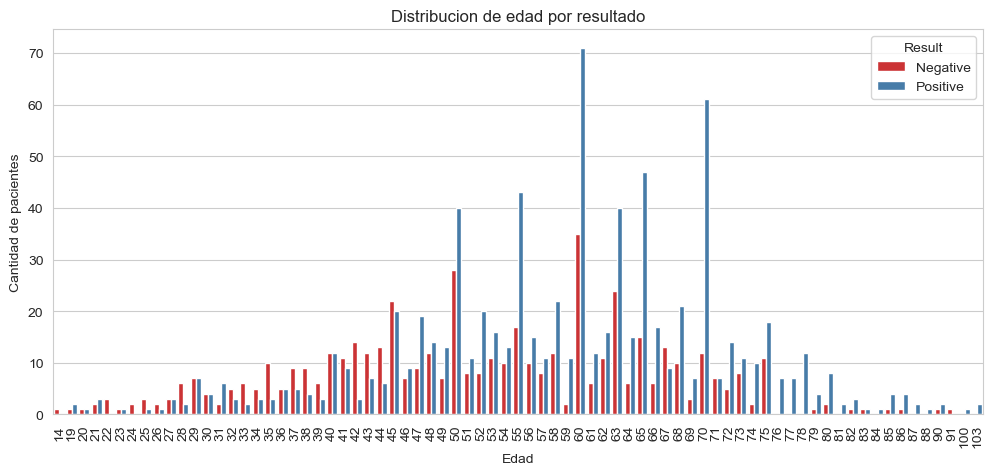

In [9]:
plt.figure(figsize=(12, 5))
ax = sns.countplot(data=data_model, x="Age", hue="Result", palette="Set1")
ax.set_title("Distribucion de edad por resultado")
ax.set_xlabel("Edad")
ax.set_ylabel("Cantidad de pacientes")
plt.xticks(rotation=90)
plt.legend(title="Result", labels=["Negative", "Positive"])
plt.show()

## 6. Revision visual de posibles valores extremos

Igual que en el notebook base, se revisan variables no binarias con graficas tipo boxplot para detectar dispersion y posibles outliers.

C:\Users\mafig\AppData\Local\Temp\ipykernel_30212\4240164271.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_model, x="Result", y=feature, ax=axes[index], palette="Set1")
C:\Users\mafig\AppData\Local\Temp\ipykernel_30212\4240164271.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_model, x="Result", y=feature, ax=axes[index], palette="Set1")
C:\Users\mafig\AppData\Local\Temp\ipykernel_30212\4240164271.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_model, x="Result", y=feature, ax=axes[index], palet

C:\Users\mafig\AppData\Local\Temp\ipykernel_30212\4240164271.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_model, x="Result", y=feature, ax=axes[index], palette="Set1")


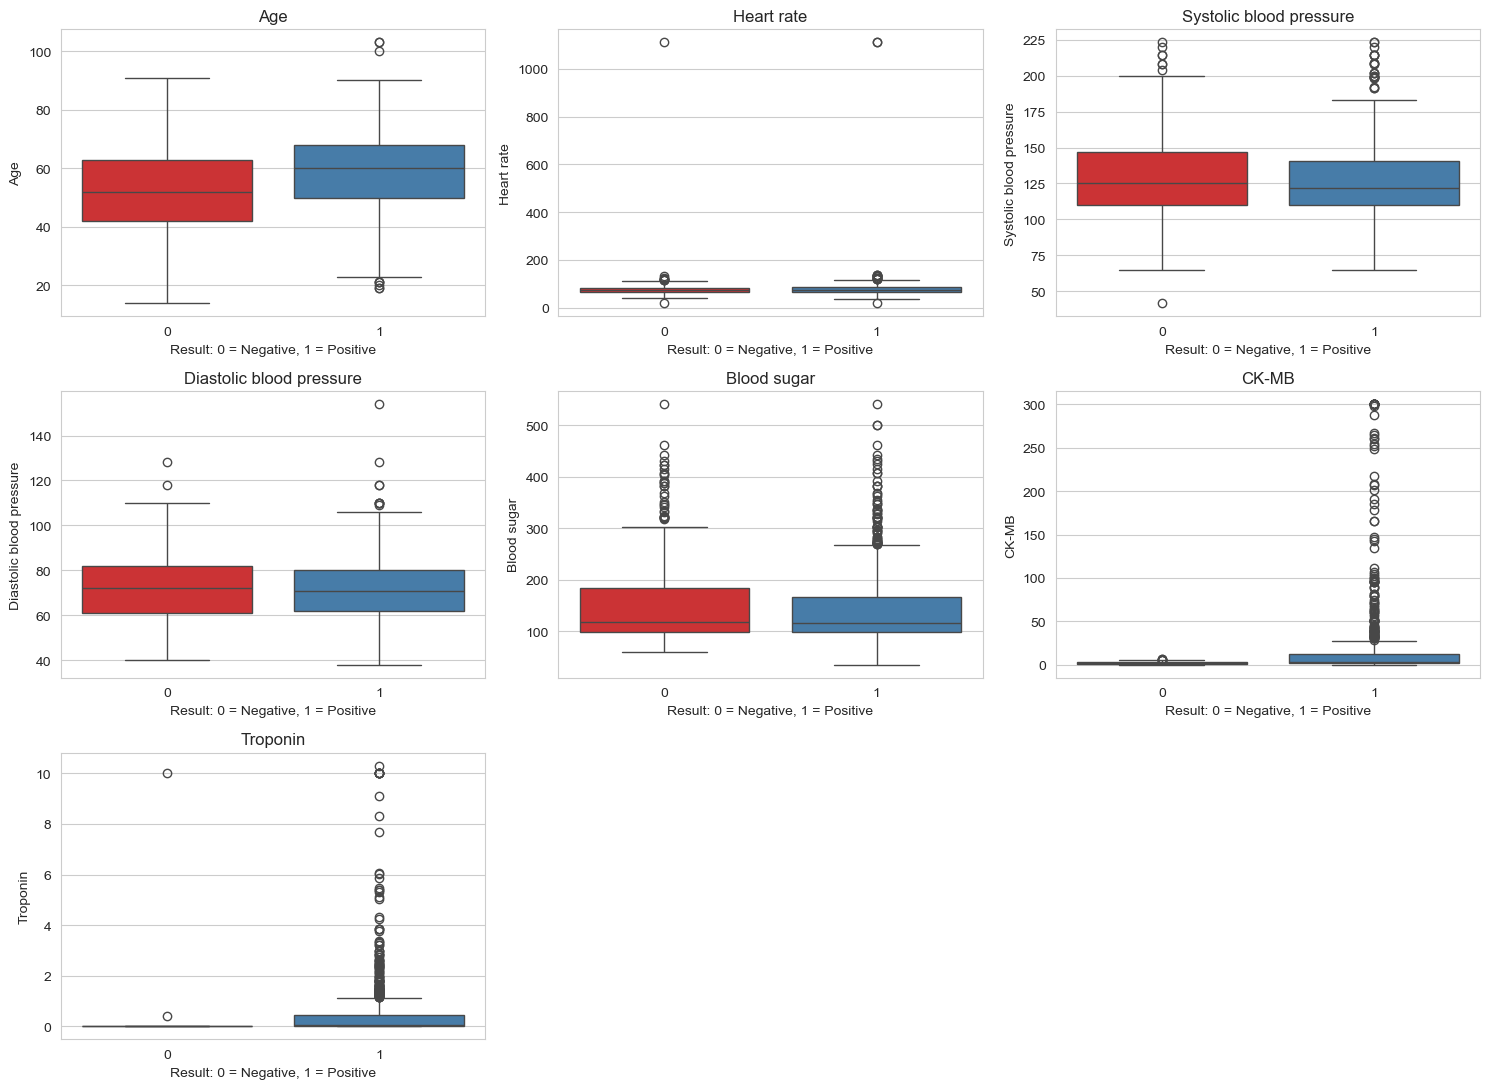

In [10]:
numeric_features = [
    "Age",
    "Heart rate",
    "Systolic blood pressure",
    "Diastolic blood pressure",
    "Blood sugar",
    "CK-MB",
    "Troponin",
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for index, feature in enumerate(numeric_features):
    sns.boxplot(data=data_model, x="Result", y=feature, ax=axes[index], palette="Set1")
    axes[index].set_title(feature)
    axes[index].set_xlabel("Result: 0 = Negative, 1 = Positive")

for index in range(len(numeric_features), len(axes)):
    axes[index].axis("off")

plt.tight_layout()
plt.show()

## 7. Separar variables predictoras y variable objetivo

- `X`: variables clinicas usadas para predecir.
- `y`: variable objetivo `Result` ya codificada.

In [11]:
X = data_model.drop(["Result"], axis=1)
y = data_model["Result"]

print(f"X: {X.shape}")
print(f"y: {y.shape}")
X.head()

X: (1319, 8)
y: (1319,)


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
0,64,1,66,160,83,160.0,1.80,0.012
1,21,1,94,98,46,296.0,6.75,1.060
2,55,1,64,160,77,270.0,1.99,0.003
3,64,1,70,120,55,270.0,13.87,0.122
4,55,1,64,112,65,300.0,1.08,0.003


## 8. Escalar variables

SVM, KNN y Regresion Logistica son sensibles a la escala de las variables. Por eso se aplica `StandardScaler` antes de entrenar.

In [12]:
col_names = list(X.columns)
print("El escalador se ajustara despues del train/test split para evitar fuga de datos.")
X.describe().T

El escalador se ajustara despues del train/test split para evitar fuga de datos.


,count,mean,std,min,25%,50%,75%,max
Age,1319.0,56.191812,13.647315,14.000,47.000,58.000,65.0000,103.0
Gender,1319.0,0.659591,0.474027,0.000,0.000,1.000,1.0000,1.0
Heart rate,1319.0,78.336619,51.630270,20.000,64.000,74.000,85.0000,1111.0
Systolic blood pressure,1319.0,127.170584,26.122720,42.000,110.000,124.000,143.0000,223.0
Diastolic blood pressure,1319.0,72.269143,14.033924,38.000,62.000,72.000,81.0000,154.0
Blood sugar,1319.0,146.634344,74.923045,35.000,98.000,116.000,169.5000,541.0
CK-MB,1319.0,15.274306,46.327083,0.321,1.655,2.850,5.8050,300.0
Troponin,1319.0,0.360942,1.154568,0.001,0.006,0.014,0.0855,10.3


## 9. Separar entrenamiento y prueba

Se conserva una division similar al notebook original: 70% entrenamiento y 30% prueba. Se agrega `stratify=y` para mantener la proporcion de clases en ambos conjuntos.

In [13]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=25,
    stratify=y,
)

s_scaler = preprocessing.StandardScaler()
X_train = pd.DataFrame(s_scaler.fit_transform(X_train_raw), columns=col_names, index=X_train_raw.index)
X_test = pd.DataFrame(s_scaler.transform(X_test_raw), columns=col_names, index=X_test_raw.index)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

X_train: (923, 8)
X_test : (396, 8)
y_train: (923,)
y_test : (396,)


## 10. Funcion de evaluacion

Para evitar repetir codigo, se define una funcion que entrena cada modelo y calcula accuracy, precision, recall, F1-score y ROC-AUC.

In [14]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        decision = model.decision_function(X_test)
        min_decision = decision.min()
        max_decision = decision.max()
        if max_decision != min_decision:
            y_proba = (decision - min_decision) / (max_decision - min_decision)

    metrics = {
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
    }

    print(f"Evaluation for {model_name}".center(75, "_"))
    for metric, value in metrics.items():
        if metric != "Modelo":
            print(f"{metric}: {value:.4f}")

    return model, y_pred, y_proba, metrics

# Model Building

## 11. Support Vector Machine

In [15]:
svm_model = svm.SVC(kernel="linear", probability=True, random_state=25)

svm_model, svm_pred, svm_proba, svm_metrics = evaluate_model(
    "Support Vector Machine",
    svm_model,
    X_train,
    X_test,
    y_train,
    y_test,
)

___________________Evaluation for Support Vector Machine___________________
Accuracy: 0.7854
Precision: 0.8559
Recall: 0.7819
F1: 0.8172
ROC-AUC: 0.8768


Confusion Matrix For Support Vector Machine:
[[121  32]
 [ 53 190]]


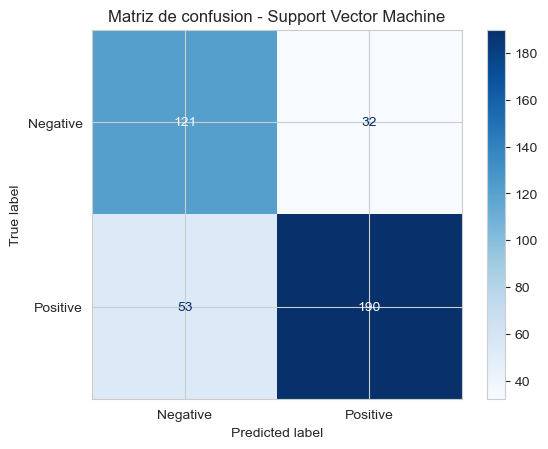

In [16]:
print("Confusion Matrix For Support Vector Machine:")
print(confusion_matrix(y_test, svm_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    display_labels=["Negative", "Positive"],
    cmap="Blues",
)
plt.title("Matriz de confusion - Support Vector Machine")
plt.show()

In [17]:
print("Classification Report For Support Vector Machine:")
print(classification_report(y_test, svm_pred, target_names=["Negative", "Positive"]))

Classification Report For Support Vector Machine:
              precision    recall  f1-score   support

    Negative       0.70      0.79      0.74       153
    Positive       0.86      0.78      0.82       243

    accuracy                           0.79       396
   macro avg       0.78      0.79      0.78       396
weighted avg       0.79      0.79      0.79       396



## 12. KNeighborsClassifier

In [18]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model, knn_pred, knn_proba, knn_metrics = evaluate_model(
    "K-Nearest Neighbors",
    knn_model,
    X_train,
    X_test,
    y_train,
    y_test,
)

_____________________Evaluation for K-Nearest Neighbors____________________
Accuracy: 0.6187
Precision: 0.6983
Recall: 0.6667
F1: 0.6821
ROC-AUC: 0.6605


Confusion Matrix For K-Nearest Neighbors:
[[ 83  70]
 [ 81 162]]


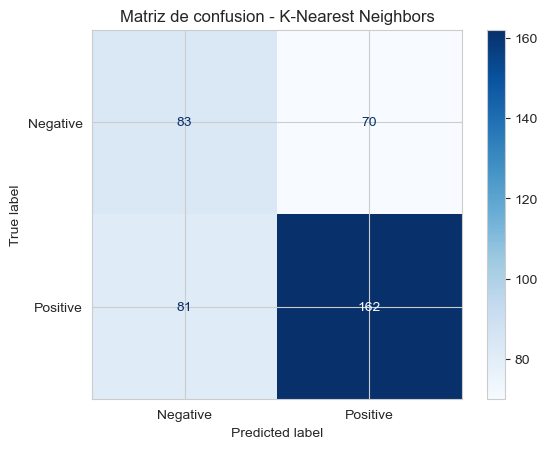

In [19]:
print("Confusion Matrix For K-Nearest Neighbors:")
print(confusion_matrix(y_test, knn_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    display_labels=["Negative", "Positive"],
    cmap="Blues",
)
plt.title("Matriz de confusion - K-Nearest Neighbors")
plt.show()

In [20]:
print("Classification Report For K-Nearest Neighbors:")
print(classification_report(y_test, knn_pred, target_names=["Negative", "Positive"]))

Classification Report For K-Nearest Neighbors:
              precision    recall  f1-score   support

    Negative       0.51      0.54      0.52       153
    Positive       0.70      0.67      0.68       243

    accuracy                           0.62       396
   macro avg       0.60      0.60      0.60       396
weighted avg       0.62      0.62      0.62       396



## 13. Logistic Regression

In [21]:
log_model = LogisticRegression(max_iter=1000, random_state=25)

log_model, log_pred, log_proba, log_metrics = evaluate_model(
    "Logistic Regression",
    log_model,
    X_train,
    X_test,
    y_train,
    y_test,
)

_____________________Evaluation for Logistic Regression____________________
Accuracy: 0.7803
Precision: 0.8197
Recall: 0.8230
F1: 0.8214
ROC-AUC: 0.8677


Confusion Matrix For Logistic Regression:
[[109  44]
 [ 43 200]]


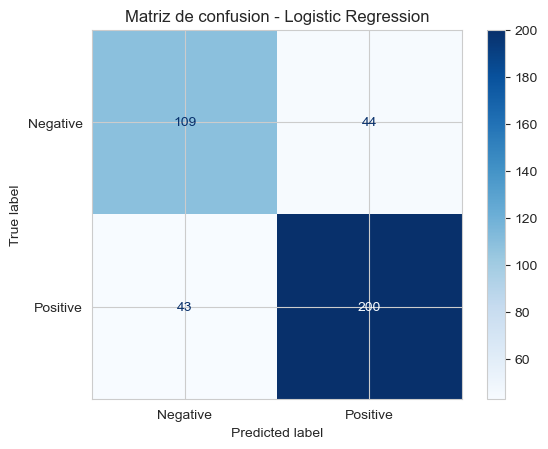

In [22]:
print("Confusion Matrix For Logistic Regression:")
print(confusion_matrix(y_test, log_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred,
    display_labels=["Negative", "Positive"],
    cmap="Blues",
)
plt.title("Matriz de confusion - Logistic Regression")
plt.show()

In [23]:
print("Classification Report For Logistic Regression:")
print(classification_report(y_test, log_pred, target_names=["Negative", "Positive"]))

Classification Report For Logistic Regression:
              precision    recall  f1-score   support

    Negative       0.72      0.71      0.71       153
    Positive       0.82      0.82      0.82       243

    accuracy                           0.78       396
   macro avg       0.77      0.77      0.77       396
weighted avg       0.78      0.78      0.78       396



# Comparacion

In [24]:
metrics_df = pd.DataFrame([svm_metrics, knn_metrics, log_metrics])
metrics_df = metrics_df.set_index("Modelo").sort_values(by="F1", ascending=False)
metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
Logistic Regression,0.780303,0.819672,0.823045,0.821355,0.867721
Support Vector Machine,0.785354,0.855856,0.781893,0.817204,0.876839
K-Nearest Neighbors,0.618687,0.698276,0.666667,0.682105,0.660534


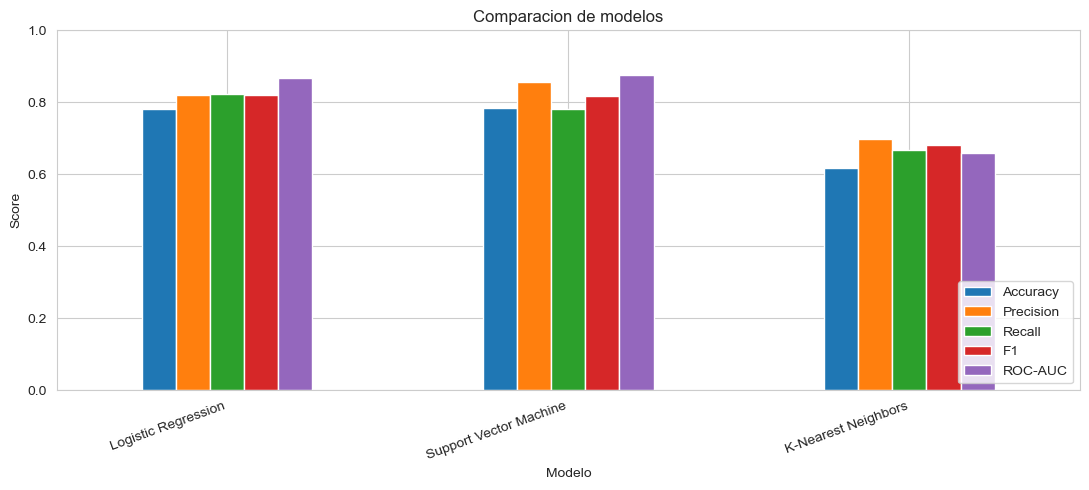

In [25]:
metrics_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(11, 5),
    ylim=(0, 1),
)
plt.title("Comparacion de modelos")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 14. Curvas ROC

La curva ROC permite comparar visualmente la capacidad de separacion de los modelos entre casos positivos y negativos.

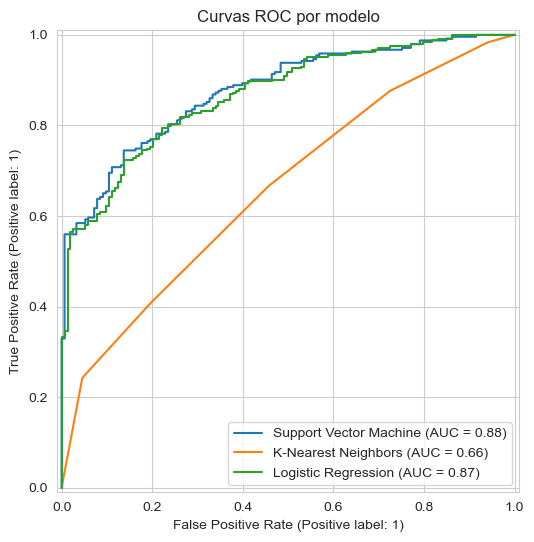

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))

probas = {
    "Support Vector Machine": svm_proba,
    "K-Nearest Neighbors": knn_proba,
    "Logistic Regression": log_proba,
}

for model_name, y_proba in probas.items():
    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_proba, name=model_name, ax=ax)

plt.title("Curvas ROC por modelo")
plt.show()

## 15. Mejor modelo segun F1-score

En problemas medicos no basta con ver accuracy. El F1-score balancea precision y recall, por eso se usa aqui para seleccionar el mejor modelo de la comparacion.

In [27]:
best_model_name = metrics_df.index[0]
best_f1 = metrics_df.loc[best_model_name, "F1"]

print(f"Mejor modelo segun F1-score: {best_model_name}")
print(f"F1-score: {best_f1:.4f}")

Mejor modelo segun F1-score: Logistic Regression
F1-score: 0.8214


## 16. Prediccion de ejemplo

Se toma un paciente del conjunto de prueba y se genera una prediccion individual con el mejor modelo.

In [28]:
models = {
    "Support Vector Machine": svm_model,
    "K-Nearest Neighbors": knn_model,
    "Logistic Regression": log_model,
}

best_model = models[best_model_name]
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0]

print("Prediccion:", "Positive" if prediction == 1 else "Negative")
print(f"P(Negative): {probability[0]:.3f}")
print(f"P(Positive): {probability[1]:.3f}")

Prediccion: Positive
P(Negative): 0.013
P(Positive): 0.987


## 17. Conclusion

En este notebook se adapto el flujo de `heart_failure.ipynb` al dataset `Medicaldataset.csv`.

Los principales cambios fueron:

1. Se cambio la carga de datos para usar `Base-de-datos/raw/Medicaldataset.csv`.
2. Se uso `Result` como variable objetivo en lugar de `DEATH_EVENT`.
3. Se codifico `Result` como `negative = 0` y `positive = 1`.
4. Se mantuvo la comparacion entre SVM, KNN y Regresion Logistica.
5. Se agregaron metricas comparables para seleccionar el mejor modelo por F1-score.

Este notebook corresponde a un problema de aprendizaje supervisado, ya que aprende patrones a partir de variables clinicas y una etiqueta conocida.

In [29]:
import json
import joblib

MODELS_DIR_CANDIDATES = [Path("../models"), Path("models")]
MODELS_DIR = next((path for path in MODELS_DIR_CANDIDATES if path.exists()), MODELS_DIR_CANDIDATES[0])
MODELS_DIR.mkdir(parents=True, exist_ok=True)

trained_models = {
    "Support Vector Machine": svm_model,
    "K-Nearest Neighbors": knn_model,
    "Logistic Regression": log_model,
}
best_model = trained_models[best_model_name]
metrics_by_model = {
    name.lower().replace(" ", "_").replace("-", "_"): {
        key.lower().replace("-", "_"): float(value)
        for key, value in row.items()
    }
    for name, row in metrics_df.to_dict(orient="index").items()
}

paro_metadata = {
    "problem": "paro_cardiaco_prediction",
    "source_dataset": "Base-de-datos/raw/Medicaldataset.csv",
    "cleaned_dataset": "Base-de-datos/cleaned/Medicaldataset_cleaned.csv",
    "target_column": "Result",
    "class_labels": {"0": "Negative", "1": "Positive"},
    "best_model": best_model_name.lower().replace(" ", "_"),
    "model_path": "models/paro_cardiaco_best_model.joblib",
    "scaler_path": "models/paro_cardiaco_scaler.joblib",
    "feature_columns": list(X.columns),
    "label_mapping": {"negative": 0, "positive": 1},
    "test_metrics_by_model": metrics_by_model,
    "preprocessing_note": "StandardScaler ajustado unicamente con X_train para evitar fuga de datos.",
}

paro_bundle = {"model": best_model, "scaler": s_scaler, "metadata": paro_metadata}
joblib.dump(best_model, MODELS_DIR / "paro_cardiaco_best_model.joblib")
joblib.dump(s_scaler, MODELS_DIR / "paro_cardiaco_scaler.joblib")
joblib.dump(paro_bundle, MODELS_DIR / "paro_cardiaco_model.joblib")
with open(MODELS_DIR / "paro_cardiaco_metadata.json", "w", encoding="utf-8") as file:
    json.dump(paro_metadata, file, ensure_ascii=False, indent=2)

print(f"Modelos de paro cardiaco guardados en: {MODELS_DIR}")

Modelos de paro cardiaco guardados en: ..\models
